<h4 STYLE=ALIGNCENTER>RANDOM FOREST</H4>

Decision Tree

   ↓

Bias–Variance Trade-off

   ↓

Ensemble Learning

   ↓

Wisdom of the Crowd

   ↓

Bootstrapping

   ↓

Bagging

   ↓

Feature Randomness

   ↓
   
Random Forest 🌲🌲🌲


#### <U>ENSEMBLE LEARNING</U>
Ensemble learning means combining predictions from multiple models to get better accuracy and robustness than a single model, and Random Forest is a classic ensemble that combines many decision trees. 

A single decision tree often has high variance and tends to overfit; combining many diverse trees reduces variance and improves performance.

<img src="ensemble-methods.png" width=400/>

benifits:
- Improvement in performance
- Bias and Variance can be reduced
- Robustness


#### <u> Voting Ensemble</u>
Voting Ensemble is an ensemble technique where multiple different models make predictions independently, and the final prediction is decided by voting or averaging of those predictions.

*Many models → one final decision*

ASSUMPTIONS:
- Models Are Independent (Ideally) : models should not depend on each other's prediction
- Each model's minimum accuracy should be 51% : else the resultant model will be worst than the worst



##### <u> BAGGING (Bootstraped Aggregation):</u>
Create many training sets by sampling the original dataset with replacement (bootstrapping), train one model on each, and then aggregate their predictions (average for regression, vote for classification).

Goal: Reduce variance

Key ideas:
- Same algorithm (usually Decision Trees , same learning algorithm multiple times (same model class), but each copy is trained on a different bootstrap sample of the data, so they become different trained models.
)
- Sampling with replacement
- Each model sees a different subset
- Models are trained independently
- Final prediction = average / majority vote

<img src="Bagging.png" legth=400; width=400/ >

here model1=model2=modeln

📌 Example:

Random Forest = Bagging + extra randomness

In [200]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [201]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [202]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [203]:
df['species']= encoder.fit_transform(df['species'])

In [204]:
#converting it to binary classification problem
df=df[df['species']!=0][['sepal_length','petal_length','species']]
df.head()

,sepal_length,petal_length,species
50,7.0,4.7,1
51,6.4,4.5,1
52,6.9,4.9,1
53,5.5,4.0,1
54,6.5,4.6,1


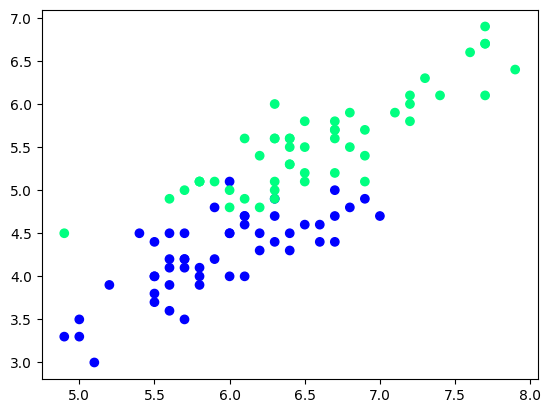

In [205]:
plt.scatter(df['sepal_length'],df['petal_length'],c=df['species'],cmap='winter')

In [206]:
#how sample function works:
df.sample(100)

,sepal_length,petal_length,species
111,6.4,5.3,2
98,5.1,3.0,1
97,6.2,4.3,1
145,6.7,5.2,2
65,6.7,4.4,1
...,...,...,...
50,7.0,4.7,1
64,5.6,3.6,1
57,4.9,3.3,1
135,7.7,6.1,2


In [207]:
inputs=df.drop('species',axis=1)
target=df['species']

##### Bagging with decision trees - RANDOM FOREST

Random Forest is an ensemble model that builds many decision trees on different bootstrapped samples and combines their outputs (majority vote for classification, averaging for regression) to reduce overfitting and improve stability. 



In [208]:
from sklearn.model_selection import train_test_split

In [209]:
X_train,X_test,y_train,y_test=train_test_split(inputs,target,test_size=0.2,random_state=42)

In [210]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

In [211]:
base_tree= DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,#to make the base tree grow to it's fullest and overfitting is encouraged
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)


The base decision tree defines the type and behavior of the model that bagging will replicate. Bagging itself does not learn patterns; it trains multiple copies of the base learner on bootstrapped datasets and aggregates their predictions. Using deep decision trees as base learners is intentional because they have high variance, which bagging is designed to reduce.

In [212]:
#Defining bagging classifier
bagging_model= BaggingClassifier(
    estimator=base_tree, # base model
    n_estimators=100 ,   # number of trees
    max_samples=0.5,     # 50% of training data
    max_features=1.0,    # use all features
    bootstrap=True,      # sampling with replacement
    bootstrap_features=False,
    oob_score=True,      # enable Out-Of_Bag evaluation
    random_state=42
)


- Feature randomness: At each split, a tree considers only a random subset of features (controlled by max_features), further reducing correlation among trees.

In [213]:
bagging_model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.5
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [214]:
y_pred=bagging_model.predict(X_test)

In [215]:
X_test.head()

,sepal_length,petal_length
133,6.3,5.1
103,6.3,5.6
120,6.9,5.7
95,5.7,4.2
94,5.6,4.2


In [216]:
bagging_model.predict([[7.4,9.0]])

d:\Data_Science\data-science\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


array([2])

In [217]:
from sklearn.metrics import classification_report,accuracy_score
print('accuracy: ',accuracy_score(y_test,y_pred))
print('model evaluation : ',classification_report(y_test,y_pred))

accuracy:  0.85
model evaluation :                precision    recall  f1-score   support

           1       0.91      0.83      0.87        12
           2       0.78      0.88      0.82         8

    accuracy                           0.85        20
   macro avg       0.84      0.85      0.85        20
weighted avg       0.86      0.85      0.85        20



print("OOB Score:", bagging_model.oob_score_)

Out-of-Bag (OOB) score is an internal validation score calculated using the data samples that were NOT used to train a particular model during bagging.


##### PASTING : 
Pasting = bagging without replacement

Pasting is an ensemble learning technique where multiple models are trained on random subsets of the training data sampled without replacement, and their predictions are then aggregated.

<img src="Sampling_with_or_without_Replacement-660.png"  width=400/>

Duplicates are actually helpful for variance reduction, which is why bagging is more popular.

##### Bagging regression:


In [218]:
from sklearn import datasets
import seaborn as sns
df=pd.read_csv('house_price.csv')

In [219]:
df.head()

,area,bedrooms,age,price
0,3974,1.0,29,660658
1,4307,1.0,18,750449
2,1660,1.0,16,258288
3,2094,3.0,18,393223
4,1930,1.0,27,271655


In [220]:
inputs=df.drop("price",axis=1)
target=df['price']

In [221]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

GridSearchCV is a method used to automatically find the best hyperparameter combination for a machine learning model by trying all possible combinations and evaluating them using cross-validation.

In [222]:
X_train1,X_test1,y_train1,y_test1=train_test_split(inputs,target,test_size=0.2,random_state=42)

In [223]:
X_test1 = X_test1[X_train1.columns]


In [224]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train1)
X_test_scaled  = scaler.transform(X_test1)   # NOT fit_transform


In [225]:
lr=LinearRegression()
dt=DecisionTreeRegressor()
knn=KNeighborsRegressor()

In [226]:

lr.fit(X_train1,y_train1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [227]:
dt.fit(X_train1,y_train1)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [228]:

knn.fit(X_train1,y_train1)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [229]:
X_test1.columns

Index(['area', 'bedrooms', 'age'], dtype='object')

In [230]:
X_train1.columns

Index(['area', 'bedrooms', 'age'], dtype='object')

In [231]:
print("X_train shape:", X_train1.shape)
print("X_test1 shape:", X_test1.shape)
print("lr coef shape:", lr.coef_.shape)


X_train shape: (176, 3)
X_test1 shape: (44, 3)
lr coef shape: (3,)


In [232]:
print(X_train1.dtypes)
print(X_test1.dtypes)


area          int64
bedrooms    float64
age           int64
dtype: object
area          int64
bedrooms    float64
age           int64
dtype: object


In [233]:
y_pred11=lr.predict(X_test1)
y_pred12=dt.predict(X_test1)
y_pred13=knn.predict(X_test1)

In [234]:
print("lr r2: ",r2_score(y_test1,y_pred11))
print("dt r2: ",r2_score(y_test1,y_pred12))
print("knn r2: ",r2_score(y_test1,y_pred13))

lr r2:  0.9883806069363379
dt r2:  0.931085154139759
knn r2:  0.9138100290083339


In [236]:
from sklearn.ensemble import BaggingRegressor


In [238]:
import numpy as np

bag_lr = BaggingRegressor(
    estimator=LinearRegression(),
    n_estimators=50,
    max_samples=0.7,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bag_lr.fit(X_train1, y_train1)

y_pred_lr = bag_lr.predict(X_test1)

print("Bagged LR R2:", r2_score(y_test1, y_pred_lr))

Bagged LR R2: 0.9882905935179702


In [239]:
from sklearn.tree import DecisionTreeRegressor

bag_dt = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=None,
        min_samples_leaf=1,
        random_state=42
    ),
    n_estimators=100,
    max_samples=0.7,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bag_dt.fit(X_train1, y_train1)

y_pred_dt = bag_dt.predict(X_test1)

print("Bagged DT R2:", r2_score(y_test1, y_pred_dt))



Bagged DT R2: 0.9660389225164905


In [240]:
from sklearn.neighbors import KNeighborsRegressor

bag_knn = BaggingRegressor(
    estimator=KNeighborsRegressor(n_neighbors=5),
    n_estimators=30,
    max_samples=0.7,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bag_knn.fit(X_train1, y_train1)

y_pred_knn = bag_knn.predict(X_test1)

print("Bagged KNN R2:", r2_score(y_test1, y_pred_knn))


Bagged KNN R2: 0.9157980668333287
